In [39]:
!pip install scikit-image==0.16.2

  Using cached scikit-image-0.16.2.tar.gz (28.9 MB)
  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.


In [41]:
!sed -i 's/multichannel=True/channel_axis=-1/g' /kaggle/working/DeepDeblur-PyTorch/**/**/*.py
!sed -i 's/multichannel=False/channel_axis=None/g' /kaggle/working/DeepDeblur-PyTorch/**/**/*.py

In [33]:
import os
os.chdir('/kaggle/working/DeepDeblur-PyTorch')
print("Current dir:", os.getcwd())
!ls

Current dir: /kaggle/working/DeepDeblur-PyTorch
DeepDeblur-PyTorch  experiment	GOPRO_L1.tar  LICENSE  README.md  src


In [44]:
import os
os.chdir('/kaggle/working/DeepDeblur-PyTorch/DeepDeblur-PyTorch')
!unzip -q GOPRO_L1.zip -d experiment/
!ls experiment/
!ls experiment/GOPRO_L1/

replace experiment/GOPRO_L1/loss.pt? [y]es, [n]o, [A]ll, [N]one, [r]ename: ^C
GOPRO_L1
args.pt   loss.pt  optim   test_loss.pdf    train_loss.pdf
args.txt  models   result  test_metric.pdf


In [46]:
!mkdir -p /kaggle/working/my_input /kaggle/working/my_output
!cp "/kaggle/input/datasets/kp0502/blurredimages/blurred traffic.jpeg" /kaggle/working/my_input/
!ls /kaggle/working/my_input/

'blurred traffic.jpeg'


In [47]:
import os
os.chdir('/kaggle/working/DeepDeblur-PyTorch/src')
print("Running from:", os.getcwd())

!python main.py \
    --save_dir GOPRO_L1 \
    --demo true \
    --demo_input_dir /kaggle/working/my_input \
    --demo_output_dir /kaggle/working/my_output

Running from: /kaggle/working/DeepDeblur-PyTorch/src
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 7 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
===> Loading demo dataset: Demo
Loss function: 1*L1
Metrics: PSNR,SSIM
===> Initializing trainer
results are saved in /kaggle/working/my_output
/kaggle/working/DeepDeblur-PyTorch/src/train.py:44: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = amp.GradScaler(
|                                                         | 0/1 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/

Input files: ['blurred traffic.jpeg']
Output files: ['blurred traffic.png']


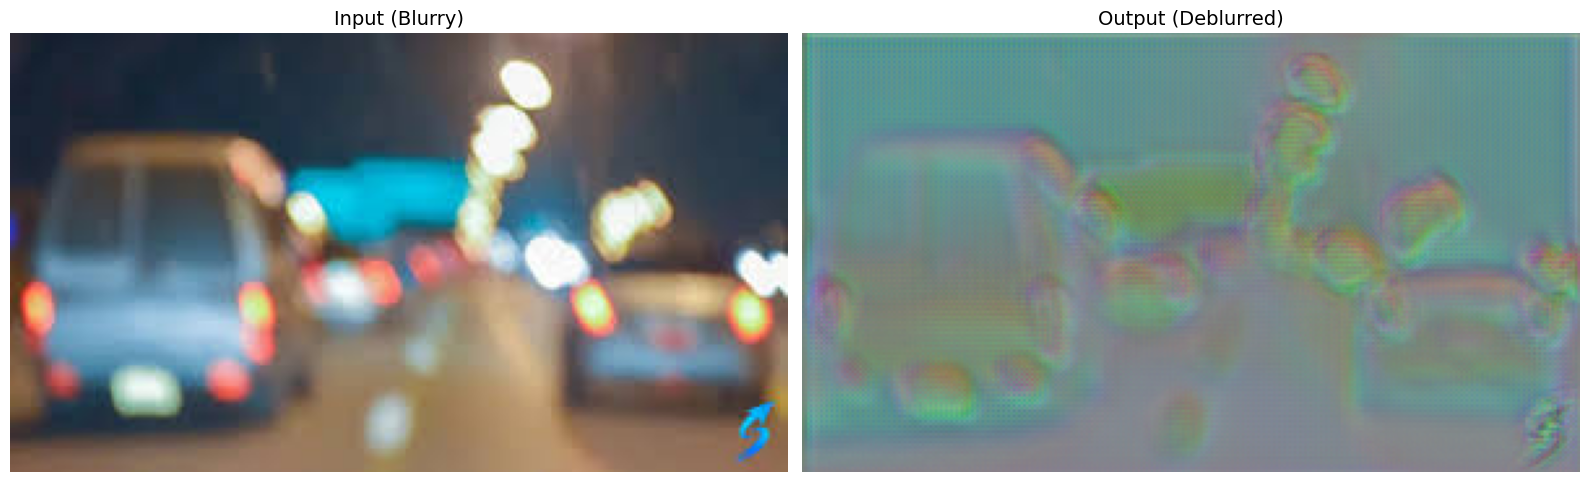

In [48]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

input_files = os.listdir("/kaggle/working/my_input")
output_files = os.listdir("/kaggle/working/my_output")

print("Input files:", input_files)
print("Output files:", output_files)

input_img = "/kaggle/working/my_input/" + input_files[0]
output_img = "/kaggle/working/my_output/" + output_files[0]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
axes[0].imshow(mpimg.imread(input_img))
axes[0].set_title("Input (Blurry)", fontsize=14)
axes[0].axis("off")
axes[1].imshow(mpimg.imread(output_img))
axes[1].set_title("Output (Deblurred)", fontsize=14)
axes[1].axis("off")
plt.tight_layout()
plt.show()